In [18]:
from typing_extensions import TypedDict, List
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
  number1: int
  number2: int
  number3: int
  number4: int
  finalNumber1 : int
  finalNumber2 : int
  operation1: str
  operation2: str

In [19]:
def add_node_1(state : AgentState) -> AgentState:
  """Node to add numbers 1 and 2"""
  state['finalNumber1'] = state['number1'] + state['number2']
  return state

def add_node_2(state : AgentState) -> AgentState:
  """Node to add numbers 3 and 4"""
  state['finalNumber1'] = state['number3'] + state['number4']
  return state

def sub_node_1(state : AgentState) -> AgentState:
  """Node to subtract numbers 1 and 2"""
  state['finalNumber2'] = abs(state['number1'] - state['number2'])
  return state

def sub_node_2(state : AgentState) -> AgentState:
  """Node to subtract numbers 3 and 4"""
  state['finalNumber2'] = abs(state['number3'] - state['number4'])
  return state


def route_1(state : AgentState) -> AgentState:
  """Node to route the operation 1"""
  if state['operation1'] == '+':
    return "addition_1"
  elif state['operation1'] == '-':
    return "subtraction_1"
  
def route_2(state : AgentState) -> AgentState:
  """Node to route the operation 1"""
  if state['operation2'] == '+':
    return "addition_2"
  elif state['operation2'] == '-':
    return "subtraction_2"
  

In [20]:
graph_builer = StateGraph(AgentState)

graph_builer.add_node("router1" , lambda state:state)
graph_builer.add_node("router2" , lambda state:state)
graph_builer.add_node("addition1", add_node_1)
graph_builer.add_node("addition2", add_node_2)
graph_builer.add_node("subtraction1", sub_node_1)
graph_builer.add_node("subtraction2", sub_node_2)

graph_builer.add_edge(START, "router1")
graph_builer.add_conditional_edges(
  "router1",
  route_1,
  {
    "addition_1" : "addition1",
    "subtraction_1" : "subtraction1"
  }
)

graph_builer.add_edge("addition1" , "router2")
graph_builer.add_edge("subtraction1" , "router2")

graph_builer.add_conditional_edges(
  "router2",
  route_2,
  {
    "addition_2" : "addition2",
    "subtraction_2" : "subtraction2"
  }
)
graph_builer.add_edge("addition2" , END)
graph_builer.add_edge("subtraction2", END)

graph = graph_builer.compile()

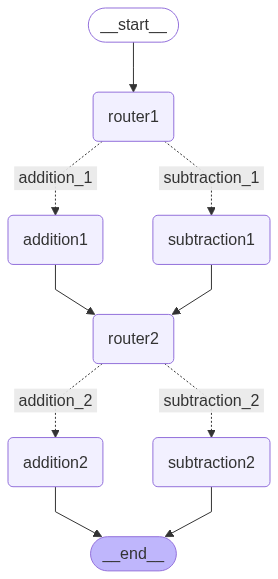

In [21]:
from IPython.display import Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
answer = graph.invoke({"number1" : 10 , "number2" : 20, "number3" : 15 , "number4" : 35, "operation1" : '+' , "operation2" : "-"})
print(answer)

{'number1': 10, 'number2': 20, 'number3': 15, 'number4': 35, 'finalNumber1': 30, 'finalNumber2': 20, 'operation1': '+', 'operation2': '-'}
